<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/Custom_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flow:

Imports

Dataset load

CNN define

Train

Accuracy print

Graph

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [7]:
# =====================
# 1. IMPORTS
# =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [8]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

In [9]:
train_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/train",transform=transform)
val_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/val",transform=transform)

In [10]:
train_loader= DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# =====================
# 3. MODEL
# =====================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*8*8,256), nn.ReLU(),
            nn.Linear(256,200)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = CNN().to(device)

In [14]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []

for epoch in range(5):
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 13914.0623
Epoch 2, Loss: 11398.7776
Epoch 3, Loss: 10590.0790
Epoch 4, Loss: 10109.2685
Epoch 5, Loss: 9710.9188


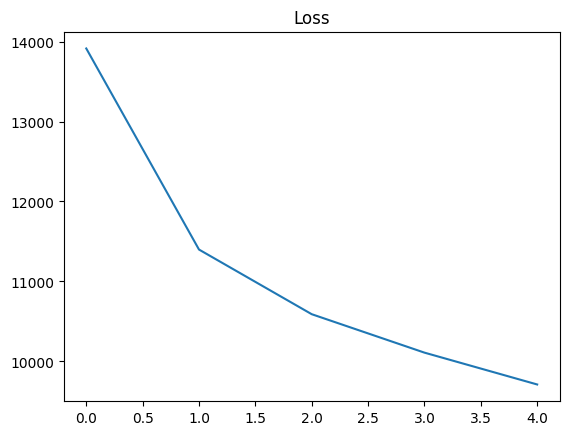

In [15]:
# =====================
# 5. GRAPH
# =====================
plt.plot(losses)
plt.title("Loss")
plt.show()


In [16]:
# =====================
# 6. ACCURACY
# =====================
model.eval()
correct, total = 0,0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs,1)
        total += labels.size(0)
        correct += (pred==labels).sum().item()

print("Accuracy:", 100*correct/total)


Accuracy: 0.56
